<a href="https://colab.research.google.com/github/ganeshkumarjer-bot/PRODIGY_ML_01/blob/main/PD_ML_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing required libraries:

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

LoadDataset:


In [26]:
# Load Kaggle dataset (train.csv)
data = pd.read_csv('/content/train.csv')

# Display first 5 rows
print(data.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [27]:
# Select input features and target variable
X = data[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = data['SalePrice']

In [28]:
# Check for missing values
print(X.isnull().sum())

# Fill missing values with mean
X = X.fillna(X.mean())

GrLivArea       0
BedroomAbvGr    0
FullBath        0
dtype: int64


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [31]:
y_pred = model.predict(X_test)

In [32]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 35788.061292436294
RMSE: 52975.71771338122
R² Score: 0.6341189942328371


In [33]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

        Feature   Coefficient
0     GrLivArea    104.026307
1  BedroomAbvGr -26655.165357
2      FullBath  30014.324109


In [34]:
# Example: 2000 sq ft, 3 bedrooms, 2 bathrooms
new_house = [[2000, 3, 2]]
predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 240377.51479736282


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Model Comparisons :

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [36]:
data = pd.read_csv("train.csv")

X = data[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = data['SalePrice']

X = X.fillna(X.mean())

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [39]:
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

In [40]:
def evaluate(y_test, y_pred):
    return {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }

In [41]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [
        evaluate(y_test, lr_pred)["MAE"],
        evaluate(y_test, dt_pred)["MAE"],
        evaluate(y_test, rf_pred)["MAE"]
    ],
    "RMSE": [
        evaluate(y_test, lr_pred)["RMSE"],
        evaluate(y_test, dt_pred)["RMSE"],
        evaluate(y_test, rf_pred)["RMSE"]
    ],
    "R2 Score": [
        evaluate(y_test, lr_pred)["R2"],
        evaluate(y_test, dt_pred)["R2"],
        evaluate(y_test, rf_pred)["R2"]
    ]
})

print(results)

               Model           MAE          RMSE  R2 Score
0  Linear Regression  35788.061292  52975.717713  0.634119
1      Decision Tree  39626.208048  57454.183894  0.569642
2      Random Forest  34115.025766  49226.368657  0.684077


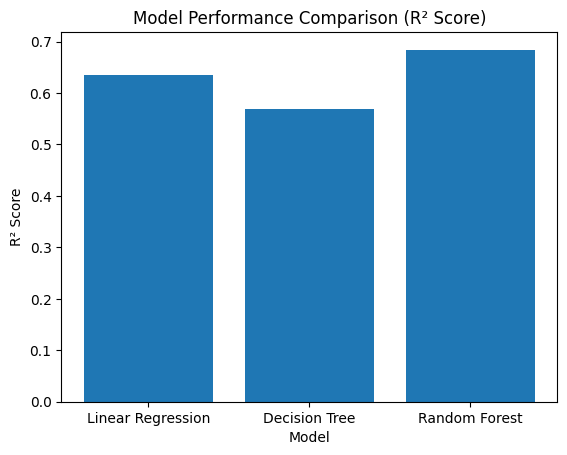

In [42]:
plt.figure()
plt.bar(results["Model"], results["R2 Score"])
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison (R² Score)")
plt.show()